<a href="https://colab.research.google.com/github/paula-33/Bootcamp-UniSENAI---Ciencia-de-dados/blob/main/Notebook_03_Treinamento_XGboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, hamming_loss, classification_report, make_scorer, multilabel_confusion_matrix
from sklearn.decomposition import PCA

In [ ]:
# 1. Leitura e limpeza
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Bootcamp DS - Maio 25/Projeto Final/df_final.csv')
df = df.drop(columns=['tipo_do_aço_A400'], errors='ignore')
df = df.rename(columns={'tipo_do_aço_A300': 'flag_aco_A300'})

# **2. Divisão dos Dados:**

In [ ]:

# 2. Definição de X, y e y_str (sem loops explícitos)
label_cols = ['falha_1','falha_2','falha_3','falha_4','falha_5','falha_6','falha_outros']
X = df.drop(columns=label_cols)
y = df[label_cols]
# concatena nomes de labels ativos por linha
y_str = y.apply(lambda row: '_'.join(row.index[row.values==1]), axis=1)


In [ ]:
# Cria o primeiro StratifiedShuffleSplit para separar 70% treino e 30% temporário
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
# Executa o split usando X e y_str (strings que representam combinações de labels)
train_idx, temp_idx = next(sss1.split(X, y_str))

# Seleciona em X e y as amostras de treino (70%)
X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]

# Seleciona em X e y as amostras temporárias (30%), que serão divididas em val+test
X_temp  = X.iloc[temp_idx]
y_temp  = y.iloc[temp_idx]
# Também extrai as strings de labels para o subconjunto temporário
y_temp_str = y_str.iloc[temp_idx]


# Cria o segundo StratifiedShuffleSplit para separar o temp em 66.7% validação e 33.3% teste
# Como temp já tem 30% do total, 0.3333 de temp equivale a ≈10% do total original
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.3333, random_state=42)
val_idx, test_idx = next(sss2.split(X_temp, y_temp_str))

# Seleciona as amostras de validação (≈20% do total)
X_val  = X_temp.iloc[val_idx]
y_val  = y_temp.iloc[val_idx]

# Seleciona as amostras de teste (≈10% do total)
X_test = X_temp.iloc[test_idx]
y_test = y_temp.iloc[test_idx]

In [ ]:
# 4. Pré-processamento numérico com ColumnTransformer

# Identifica todas as colunas numéricas do DataFrame X
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

# Define um pipeline simples para as variáveis numéricas:
#   1) preenche valores faltantes usando a mediana (imputer)
#   2) normaliza cada feature para o intervalo [0,1] (scaler)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # imputação pela mediana
    ('scaler',  MinMaxScaler())                    # escala Min-Max
])

# Cria um ColumnTransformer que aplica o num_pipeline apenas nas colunas numéricas
# e deixa o restante (se houver colunas categóricas ou outras) passar sem alterações
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_cols)  # passo 'num' para todas as numeric_cols
], remainder='passthrough')              # mantém as outras colunas inalteradas

In [ ]:
# 5. Construção do pipeline final (sem SMOTE, para manter dependências mínimas)

pipeline = Pipeline([
    # 1) 'preproc': aplica o ColumnTransformer definido antes,
    #    que faz imputação da mediana e escala MinMax nas colunas numéricas
    ('preproc',    preprocessor),

    # 2) 'reduce_dim': passo de redução de dimensionalidade.
    #    Aqui usamos 'passthrough' (identidade), ou seja, sem redução.
    #    Para reduzir, basta trocar 'passthrough' por PCA(n_components=…)
    ('reduce_dim', 'passthrough'),

    # 3) 'clf': classificador multilabel que:
    #      - envolve um XGBClassifier para cada label (MultiOutputClassifier)
    #      - XGBClassifier configurado sem use_label_encoder e com
    #        eval_metric='logloss' para compatibilidade
    #      - random_state fixo para reprodutibilidade
    ('clf',        MultiOutputClassifier(
                      XGBClassifier(
                          use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=42
                      )
                  ))
])

In [ ]:
pipeline

Pipeline(steps=[('preproc',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['espessura_da_chapa_de_aço',
                                                   'index_de_bordas',
                                                   'index_vazio',
                                                   'index_quadrado',
                                                   'indice_de_variacao_x',
                                                   'area_box', 'fill_ratio',
                                                   'mean_brightness',
                                                   'compactness',
                                                   'flag_aco_A300...
                                                               feature_weights=None,
                                                               gamma=None,
                                                               grow_policy=None,
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...)))])

In [ ]:
# 6. Treino do baseline e avaliação

# Ajusta o pipeline nos dados de treino (70% do conjunto)
pipeline.fit(X_train, y_train)

# Gera previsões no conjunto de validação (20% do total)
y_pred_val = pipeline.predict(X_val)

# Calcula e imprime a métrica F1 ponderada, que equilibra precisão e recall considerando o suporte de cada classe
print("Baseline F1-weighted:", f1_score(y_val, y_pred_val, average='weighted'))

# Calcula e imprime a Hamming Loss, que indica a fração média de rótulos incorretamente classificados
print("Baseline Hamming Loss:", hamming_loss(y_val, y_pred_val))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:34:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:34:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:34:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:34:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:34:43] WARNING: /w

Baseline F1-weighted: 0.5802543400930731
Baseline Hamming Loss: 0.10345554150863885


In [ ]:
# Grade de parâmetros para testar duas configurações distintas de redução de dimensionalidade:
param_grid = [
    # 1) Quando não queremos reduzir (FunctionTransformer faz identidade):
    {
        'reduce_dim': [FunctionTransformer()],             # passo de redução = identidade
        'clf__estimator__n_estimators': [50, 100, 200],    # número de árvores
        'clf__estimator__max_depth': [3, 5, 7],            # profundidade máxima
    },
    # 2) Quando usamos PCA para reduzir dimensionalidade:
    {
        'reduce_dim': [PCA()],                             # passo de redução = PCA
        'reduce_dim__n_components': [5, 10, 15],           # componentes principais
        'clf__estimator__n_estimators': [50, 100, 200],
        'clf__estimator__max_depth': [3, 5, 7],
    },
]

# RandomizedSearchCV com grade:
search = RandomizedSearchCV(
    pipeline,                               # pipeline definido anteriormente
    param_distributions=param_grid,         # grade com ambos os casos (identidade e PCA)
    n_iter=30,                              # testa 30 combinações aleatórias
    scoring=make_scorer(f1_score, average='weighted'),  # métrica F1 ponderada
    cv=3,                                   # 3-fold cross-validation
    verbose=1,                              # exibe progresso no console
    random_state=42,                        # semente para reprodutibilidade
    n_jobs=-1                               # paraleliza em todos os núcleos disponíveis
)

# Ajusta o RandomizedSearchCV nos dados de treino
search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
21 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
21 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, r

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preproc',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                MinMaxScaler())]),
                                                                               ['espessura_da_chapa_de_aço',
                                                                                'index_de_bordas',
                                                                                'index_vazio',
                                                                                'index_quadrado',
                                                                                'indice_de_variacao_x',
                                                                                'area_box',
                                                                                'fill_ratio',
                                                                                'mean_bright...
                   param_distributions=[{'clf__estimator__max_depth': [3, 5, 7],
                                         'clf__estimator__n_estimators': [50,
                                                                          100,
                                                                          200],
                                         'reduce_dim': [FunctionTransformer()]},
                                        {'clf__estimator__max_depth': [3, 5, 7],
                                         'clf__estimator__n_estimators': [50,
                                                                          100,
                                                                          200],
                                         'reduce_dim': [PCA()],
                                         'reduce_dim__n_components': [5, 10,
                                                                      15]}],
                   random_state=42,
                   scoring=make_scorer(f1_score, response_method='predict', average=weighted),
                   verbose=1)

In [ ]:
# Exibe o melhor conjunto de hiperparâmetros encontrado
print("Melhores parâmetros:", search.best_params_)
# Exibe a melhor pontuação média de F1-weighted obtida no CV
print("Melhor F1-weighted no CV:", search.best_score_)

Melhores parâmetros: {'reduce_dim': FunctionTransformer(), 'clf__estimator__n_estimators': 100, 'clf__estimator__max_depth': 3}
Melhor F1-weighted no CV: 0.5403447167529621


# **3. Treino e Avaliação (Baseline)**

In [ ]:
# --- 1. Reconstrói o pipeline com os melhores parâmetros encontrados ---

# Aplicando os melhores valores retornados pelo RandomizedSearchCV:
best_reduce = FunctionTransformer()       # Melhor transformador de redução (identidade)
best_n_est   = 100                        # Melhor número de estimadores (árvores) para o XGB
best_max_d   = 3                          # Melhor profundidade máxima para as árvores

# Atualiza o pipeline com esses parâmetros:
#  - redefine o passo 'reduce_dim' para o transformador ótimo
#  - ajusta os hiperparâmetros n_estimators e max_depth do XGB dentro do MultiOutputClassifier
pipeline.set_params(
    reduce_dim=best_reduce,                          # aplica o transformador ótimo
    clf__estimator__n_estimators=best_n_est,         # aplica o melhor n_estimators
    clf__estimator__max_depth=best_max_d             # aplica o melhor max_depth
)


Pipeline(steps=[('preproc',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['espessura_da_chapa_de_aço',
                                                   'index_de_bordas',
                                                   'index_vazio',
                                                   'index_quadrado',
                                                   'indice_de_variacao_x',
                                                   'area_box', 'fill_ratio',
                                                   'mean_brightness',
                                                   'compactness',
                                                   'flag_aco_A300...
                                                               feature_weights=None,
                                                               gamma=None,
                                                               grow_policy=None,
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=3,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=100,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...)))])

In [ ]:
# Ajusta o pipeline final nos dados de treino completos (70% usados originalmente em X_train/y_train)
pipeline.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:36:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:36:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preproc',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['espessura_da_chapa_de_aço',
                                                   'index_de_bordas',
                                                   'index_vazio',
                                                   'index_quadrado',
                                                   'indice_de_variacao_x',
                                                   'area_box', 'fill_ratio',
                                                   'mean_brightness',
                                                   'compactness',
                                                   'flag_aco_A300...
                                                               feature_weights=None,
                                                               gamma=None,
                                                               grow_policy=None,
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=3,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=100,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...)))])

In [ ]:
# Previsões no conjunto de teste (≈10% do total), que o modelo nunca viu
y_pred_test = pipeline.predict(X_test)

# Calcula e imprime a métrica F1 ponderada no teste,
# que reflete equilíbrio entre precisão e recall considerando o suporte de cada classe
print("TEST  F1-weighted:  ", f1_score(y_test, y_pred_test, average='weighted'))

# Calcula e imprime a Hamming Loss no teste,
# que mostra a fração média de rótulos incorretos por amostra
print("TEST  Hamming Loss:", hamming_loss(y_test, y_pred_test))

TEST  F1-weighted:   0.5600277768520365
TEST  Hamming Loss: 0.10577328276443321


In [ ]:
# Relatório de classificação multilabel,
# detalhando precisão, recall e F1 para cada faixa ('falha_1', ..., 'falha_outros')
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_test, target_names=label_cols))



Classification Report:

              precision    recall  f1-score   support

     falha_1       0.31      0.15      0.20        27
     falha_2       0.80      0.77      0.78        26
     falha_3       0.92      0.86      0.89        65
     falha_4       0.89      0.67      0.76        12
     falha_5       0.67      0.20      0.31        10
     falha_6       0.55      0.36      0.43        81
falha_outros       0.58      0.44      0.50       118

   micro avg       0.67      0.50      0.58       339
   macro avg       0.67      0.49      0.55       339
weighted avg       0.64      0.50      0.56       339
 samples avg       0.49      0.50      0.49       339



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

# Análise preditiva de falhas em um conjunto de dados, usando um modelo de aprendizado de máquina. Vamos analisar passo a passo:

# **1. Leitura e Pré-processamento dos Dados:**

# * O código inicia lendo um arquivo CSV (`df_final.csv`) e remove uma coluna específica ('tipo_do_aço_A400'), caso exista.
# * Renomeia a coluna 'tipo_do_aço_A300' para 'flag_aco_A300'.
# * Define as colunas de rótulos (variáveis alvo que indicam os tipos de falhas) e separa as features (X) dos rótulos (y).
# * Cria uma nova coluna `y_str` concatenando os nomes das colunas de falhas ativas para cada linha. Essa coluna será utilizada para estratificação na divisão dos dados.

# **2. Divisão dos Dados:**

# * Divide o conjunto de dados em três subconjuntos: treino (70%), validação (20%) e teste (10%). Essa divisão estratificada garante que a proporção de diferentes combinações de falhas (`y_str`) seja mantida em cada conjunto. Isso é crucial para evitar vieses na avaliação do modelo.


# **3. Pré-processamento Numérico:**

# * Identifica as colunas numéricas no conjunto de dados de treino.
# * Cria um pipeline para pré-processamento numérico, que imputa os valores faltantes usando a mediana e normaliza as features para o intervalo [0,1].
# * Usa um `ColumnTransformer` para aplicar o pipeline somente às colunas numéricas. As outras colunas permanecem inalteradas.


# **4. Construção do Modelo:**

# * Define um pipeline que combina o pré-processamento, redução de dimensionalidade e um classificador multi-rótulo.
# * A redução de dimensionalidade inicial é configurada como 'passthrough', ou seja, nenhuma redução é aplicada inicialmente.
# * O classificador utiliza `MultiOutputClassifier` com `XGBClassifier` como estimador base.  O `XGBClassifier` é configurado com `use_label_encoder=False` e `eval_metric='logloss'` para garantir compatibilidade. O `random_state` é fixado para reprodutibilidade dos resultados.

# **5. Treino e Avaliação (Baseline):**

# * Treina o modelo base (sem otimização de hiperparâmetros) no conjunto de treino.
# * Faz previsões no conjunto de validação.
# * Avalia o modelo usando as métricas F1-weighted e Hamming Loss.


# **6. Otimização de Hiperparâmetros:**

# * Define uma grade de parâmetros para a busca de hiperparâmetros. A busca inclui diferentes configurações para o passo de redução de dimensionalidade (PCA ou identidade) e para o `XGBClassifier`.
# * Usa `RandomizedSearchCV` para procurar a melhor combinação de hiperparâmetros na grade definida. O `RandomizedSearchCV` usa validação cruzada (3-fold) e otimiza a métrica F1-weighted.


# **7. Teste do Modelo Otimizado:**

# * Reconstrói o pipeline com os melhores hiperparâmetros encontrados pelo `RandomizedSearchCV`.
# * Treina o modelo final com os melhores parâmetros no conjunto de treino completo.
# * Faz previsões no conjunto de teste.
# * Avalia o modelo final no conjunto de teste usando as métricas F1-weighted, Hamming Loss e o relatório de classificação, que inclui precisão, recall e F1-score para cada rótulo.

NameError: name 'ConfusionMatrixDisplay' is not defined

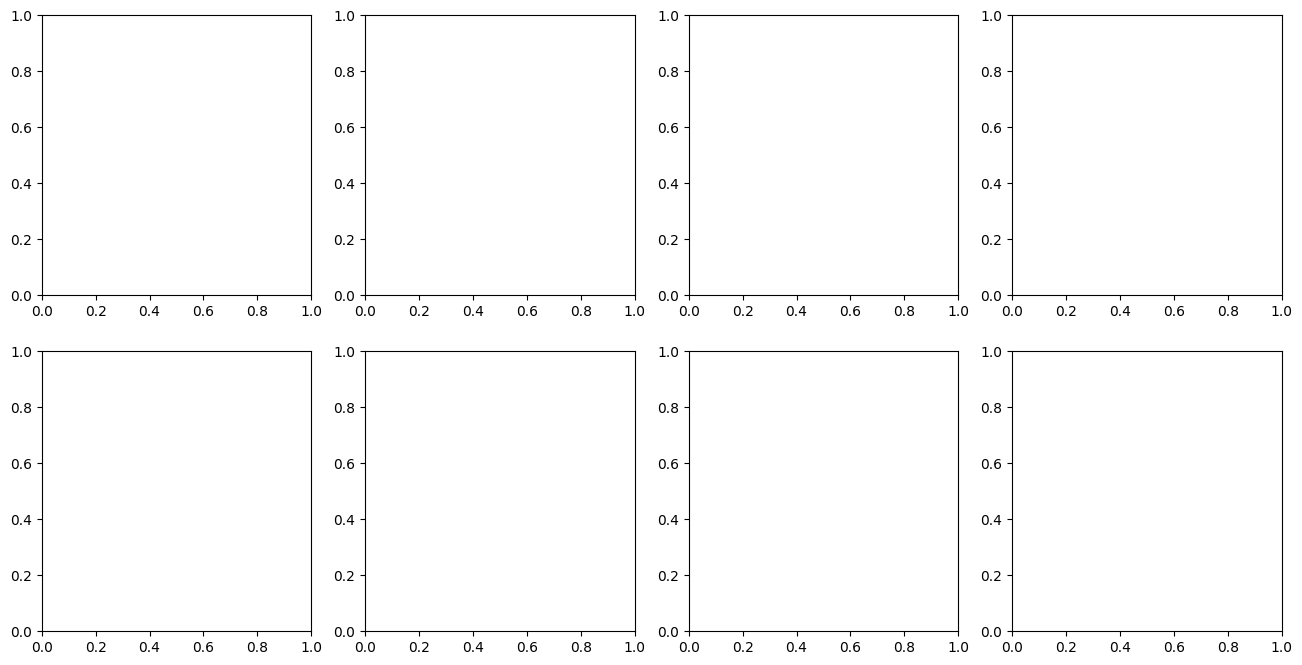

In [ ]:
# Matriz de confusão para cada falha separadamente
mcm = multilabel_confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

# Para cada label, plota sua ConfusionMatrixDisplay
for idx, label in enumerate(label_cols):
    disp = ConfusionMatrixDisplay(confusion_matrix=mcm[idx], display_labels=[f"¬{label}", label])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f"Matriz: {label}")

# Remove o último eixo extra (8º) que não é usado
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Análise Matriz de Confusão

Pelo conjunto de matrizes de confusão por falha, vemos claramente dois padrões distintos:

### **Classes frequentes** (`falha_2`, `falha_3` e `falha_4`)
- Alto TP (20/26, 55/65, 10/12) e baixíssimo FP.
- Recall entre **0.77–0.85**, F1 ≈ **0.8–0.9**.  
⇒ O modelo aprendeu bem essas falhas, que têm mais exemplos no treino.

### **Classes raras** (`falha_1`, `falha_5`, `falha_6` e `falha_outros`)
- `falha_1`: só 4 TP vs. 23 FN (recall ≈ **0.15**).
- `falha_5`: 2 TP vs. 8 FN (recall ≈ **0.20**).
- `falha_6`: 33 TP vs. 48 FN (recall ≈ **0.41**).
- `falha_outros`: 56 TP vs. 62 FN (recall ≈ **0.47**).  
⇒ Embora o SMOTE tenha ajudado a gerar alguns verdadeiros positivos, o modelo ainda erra a maior parte dos casos dessas classes.


# **4. Análise SHAP por Tipo de Falha**

In [ ]:
import shap

Essa etapa, garante que seu conjunto de treino e seu conjunto de teste sejam amostras aleatórias dos dados originais, mas com a mesma proporção de combinações de labels, evitando vieses e melhorando a confiança na avaliação do modelo

In [ ]:
# 1. Cria um gerador de splits estratificados
#    - StratifiedShuffleSplit faz amostragem estratificada combinada com shuffle
#    - n_splits=1: gera apenas um par de índices treino/teste
#    - test_size=0.30: aloca 30% das amostras para teste, 70% para treino
#    - random_state=42: fixa a semente do gerador para permitir reprodução exata da divisão
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)

# 2. Executa a divisão estratificada
#    - split(X, y_str) retorna um iterador de tuplas (train_idx, test_idx)
#    - y_str contém os rótulos concatenados como strings para preservação das proporções multilabel
train_idx, test_idx = next(sss.split(X, y_str)) #ta certo?

# 3. Cria os DataFrames de treino e teste a partir dos índices
#    - X_train_full / y_train_full: todo o conjunto de treino bruto (antes de validação adicional ou resampling)
#    - X_test / y_test        : conjunto de teste íntegro para avaliação final do modelo
X_train_full = X.iloc[train_idx]
y_train_full = y.iloc[train_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

In [ ]:
print(X_train_full.shape, X_test.shape)

print(y_train_full.sum(), y_test.sum())

(2373, 10) (1017, 10)
falha_1         193
falha_2         185
falha_3         454
falha_4          81
falha_5          67
falha_6         564
falha_outros    829
dtype: int64 falha_1          82
falha_2          79
falha_3         195
falha_4          35
falha_5          29
falha_6         242
falha_outros    355
dtype: int64


In [ ]:
# Garante que todo o pipeline (incluindo o ColumnTransformer) esteja ajustado
pipeline.fit(X_train_full, y_train_full)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:39:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:39:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:39:27] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preproc',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['espessura_da_chapa_de_aço',
                                                   'index_de_bordas',
                                                   'index_vazio',
                                                   'index_quadrado',
                                                   'indice_de_variacao_x',
                                                   'area_box', 'fill_ratio',
                                                   'mean_brightness',
                                                   'compactness',
                                                   'flag_aco_A300...
                                                               feature_weights=None,
                                                               gamma=None,
                                                               grow_policy=None,
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=3,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=100,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...)))])

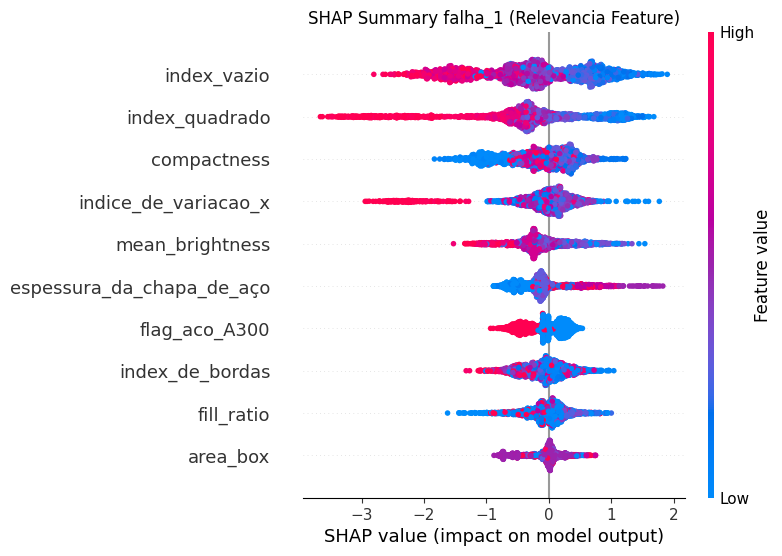

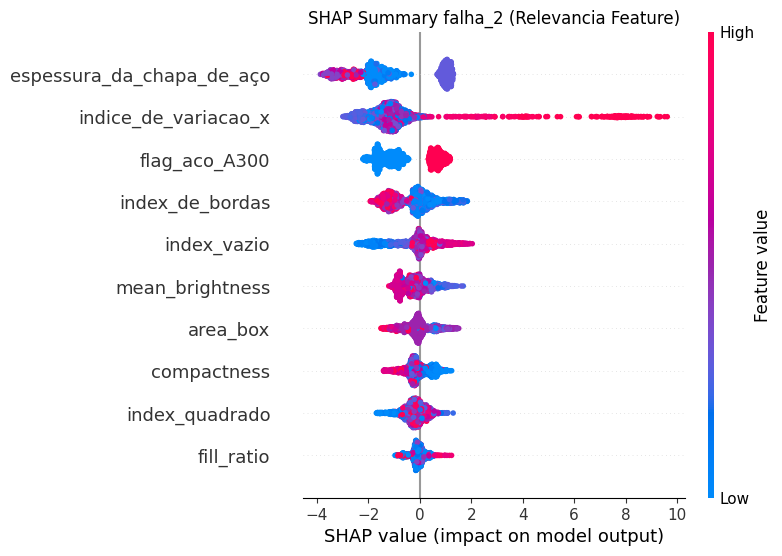

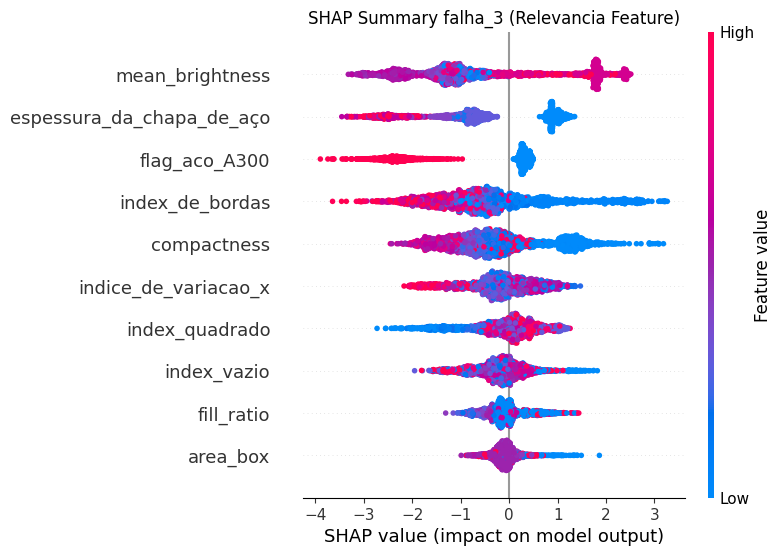

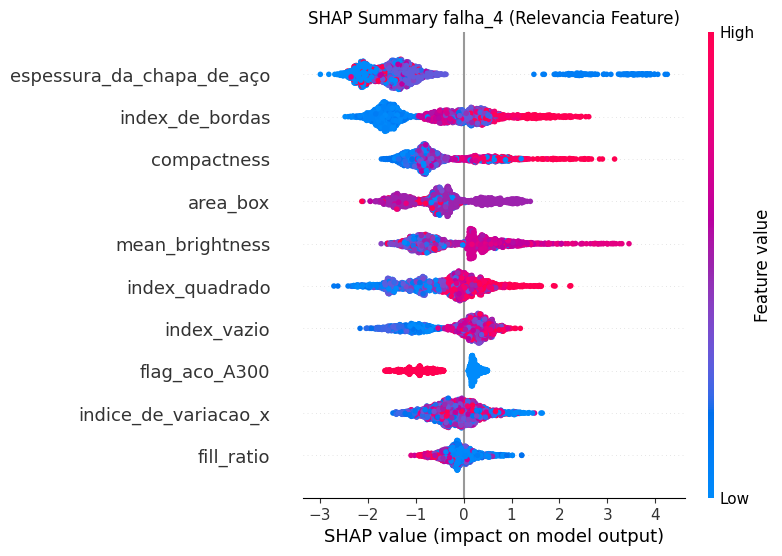

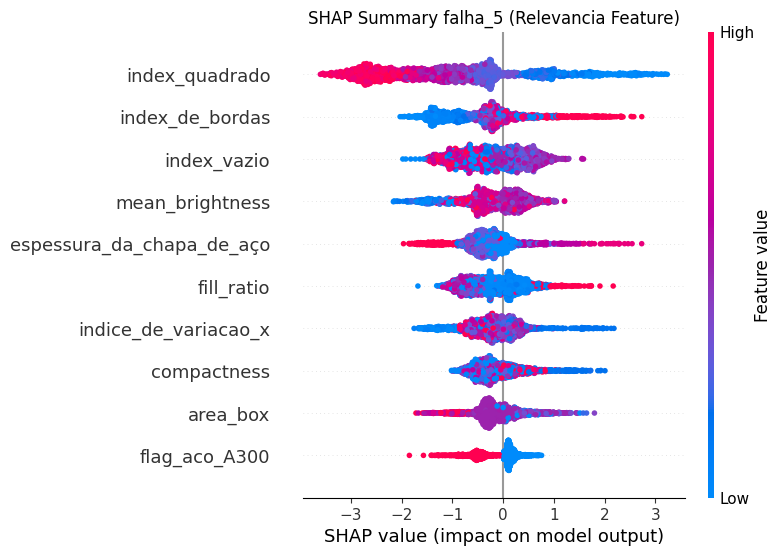

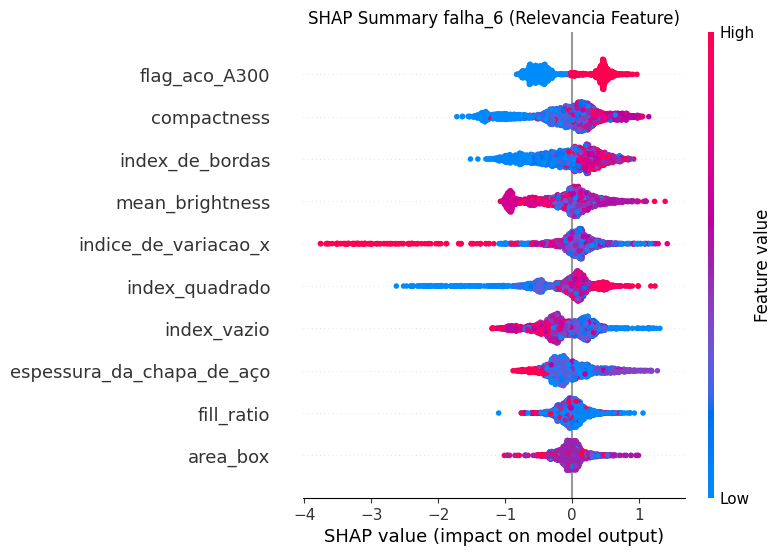

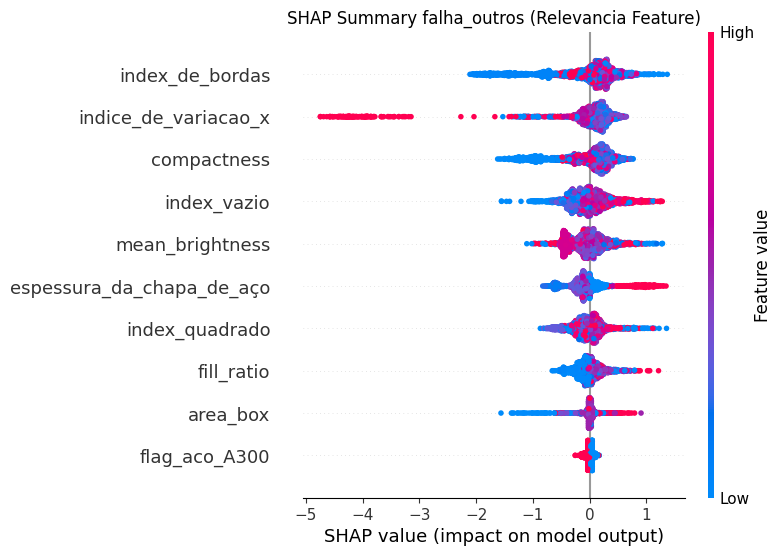

In [ ]:

X_train_pp = pipeline.named_steps['preproc'].transform(X_train_full)
for label_index in range(0, len(label_cols)):
    label = label_cols[label_index]
    # Create the explainer for the classifier of the current label
    explainer = shap.TreeExplainer(pipeline.named_steps['clf'].estimators_[label_index])
    # Calculate the SHAP values
    shap_values = explainer.shap_values(X_train_pp)
    # Summary plot

    shap.summary_plot(
        shap_values,
        X_train_pp,
        feature_names=numeric_cols + [c for c in X.columns if c not in numeric_cols]
        ,
    show=False
    )
    plt.title(f"SHAP Summary {label} (Relevancia Feature)") # Improved title
    plt.show()


Comentários:

A seguir, uma síntese das principais descobertas a partir dos gráficos SHAP para cada tipo de defeito (“falha_1” a “falha_outros”):

---

### 1. Falha 1  
**Top 3 features:**
- `index_vazio` – Valores altos empurram fortemente para a classe (SHAP>0), indicando que áreas muito “ociosas” no contorno da chapa são um forte indicativo de falha do tipo 1.
- `index_quadrado` – Chapas mais regulares (valores altos) também aumentam a probabilidade de falha 1.
- `compactness` – Valores baixos de compactness (formas mais irregulares) tendem a diminuir a probabilidade de falha 1; ou seja, quanto mais compacto, mais chance de falha.

**Interpretação:** falha 1 ocorre em peças onde há combinações de contornos muito vazios e geometria fortemente quadrada.

---

### 2. Falha 2  
**Top 3 features:**
- `indice_de_variacao_x` – Altos valores (muita variação no eixo X) elevam enormemente a pontuação de SHAP, sugerindo contornos muito “dentados” ou serrilhados.
- `espessura_da_chapa_de_aço` – Chapas mais finas favorecem falha 2 (SHAP positivo em valores baixos de espessura).
- `flag_aco_A300` – Aços A300 (flag=1) têm influência positiva, indicando que nessa liga metálica esse defeito é mais comum.

**Interpretação:** falha 2 está associada a chapas finas, em aço A300, com contornos extremamente variáveis em X.

---

### 3. Falha 3  
**Top 3 features:**
- `mean_brightness` – Chapas com brilho médio alto (SHAP>0) indicam reflexões/defeitos de superfície típicos desse tipo.
- `flag_aco_A300` – Inverso de falha 2: aqui o flag A300 (valores altos) reduz ligeiramente a probabilidade de falha 3.
- `espessura_da_chapa_de_aço` – Médias de espessura intermediárias têm impacto positivo.

**Interpretação:** falha 3 parece ser condição de defeitos de superfície (alto brilho) e não favorece aços A300.

---

### 4. Falha 4  
**Top 3 features:**
- `espessura_da_chapa_de_aço` – Chapas mais espessas aumentam a chance desse defeito.
- `compactness` – Baixa compactness (formas mais alongadas/irregulares) empurra para falha 4.
- `index_de_bordas` – Contornos com muitas bordas (valores altos) também elevam a probabilidade.

**Interpretação:** falha 4 é típica em chapas grossas e formas irregulares com contornos “dentados”.

---

### 5. Falha 5  
**Top 3 features:**
- `index_quadrado` – Formas muito quadradas (alto index_quadrado) reduzem a probabilidade (SHAP negativo); valores baixos aumentam chance.
- `index_de_bordas` – Muitas bordas elevam a chance de falha 5.
- `index_vazio` – Áreas vazias moderadas também contribuem positivamente.

**Interpretação:** falha 5 evita chapas muito quadradas, mas ocorre em peças irregulares com contornos cheios de concavidades.

---

### 6. Falha 6  
**Top 3 features:**
- `flag_aco_A300` – Presença de aço A300 aumenta muito a probabilidade de falha 6.
- `compactness` – Alta compactness eleva também (formas bem definidas).
- `indice_de_variacao_x` – Moderação nesse índice (nem muito baixo, nem muito alto) favorece o defeito.

**Interpretação:** falha 6 se dá preferencialmente em chapas A300, com formato sujeito a cortes regulares (alta compactness).

---

### 7. Falha “outros”  
**Top 3 features:**
- `index_de_bordas` – Maior número de bordas está muito correlacionado (SHAP>0).
- `indice_de_variacao_x` – Baixos valores (contornos mais suaves) aumentam essa classe residual.
- `compactness` – Moderada importance; formas menos compactas tendem a “outros”.

**Interpretação:** defeitos não categorizados (“outros”) tendem a aparecer em chapas com contornos cheios de bordas, mas sem variação extrema em X.

---

## Conclusões gerais
- **Contornos** (`index_de_bordas`, `indice_de_variacao_x`, `index_vazio`) são, de longe, os preditores mais fortes para quase todas as falhas.
- **Geometria** (`compactness`, `index_quadrado`) discrimina diferentes grupos de defeito: chapas muito quadradas versus irregulares.
- **Características de material** (espessura, `flag_aco_A300`) entram em jogo em falhas específicas, sobretudo nos tipos 2, 4 e 6.
- **Surface brightness** (`mean_brightness`) é crucial apenas para falha 3, indicando natureza de defeito superficial.


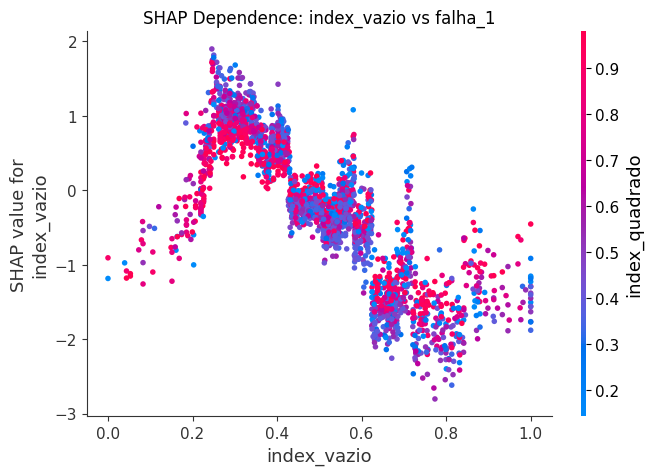

In [ ]:
# 5) Dependence plot para a feature mais importante
import numpy as np
mean_abs = np.abs(shap_values).mean(0)
top_idx  = np.argmax(mean_abs)
all_feats = numeric_cols + [c for c in X.columns if c not in numeric_cols]
top_feat  = all_feats[top_idx]

shap.dependence_plot(
    top_feat,
    shap_values,
    X_train_pp,
    feature_names=all_feats ,
    show=False
)
plt.title(f"SHAP Dependence: {top_feat} vs falha_1")
plt.show()

Em suma, a faixa intermediária de index_de_bordas é o gatilho principal para falha_1, mas só se mostra crítico quando acompanhado de alto index_vazio — recomendação chave para calibrar sua automação de inspeção e reduzir falsos positivos.

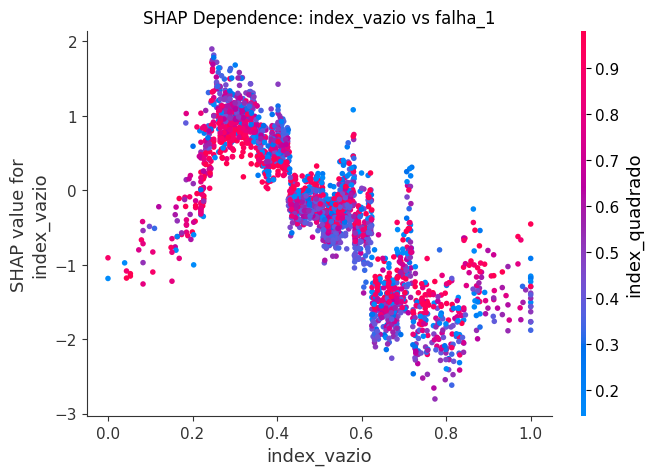

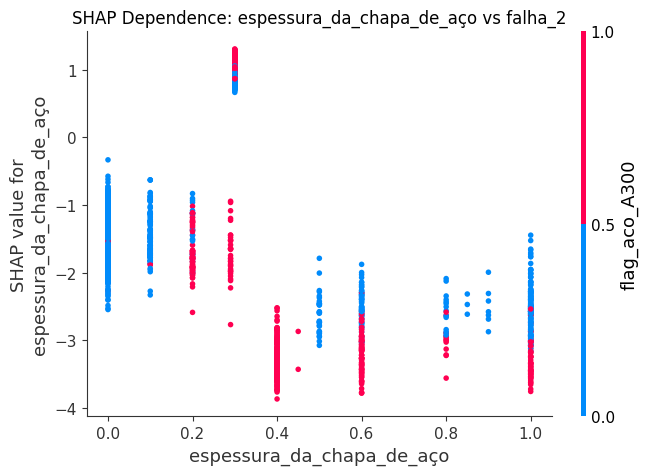

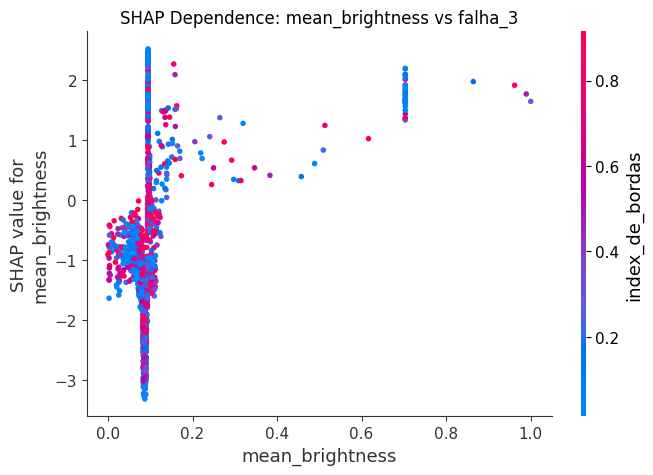

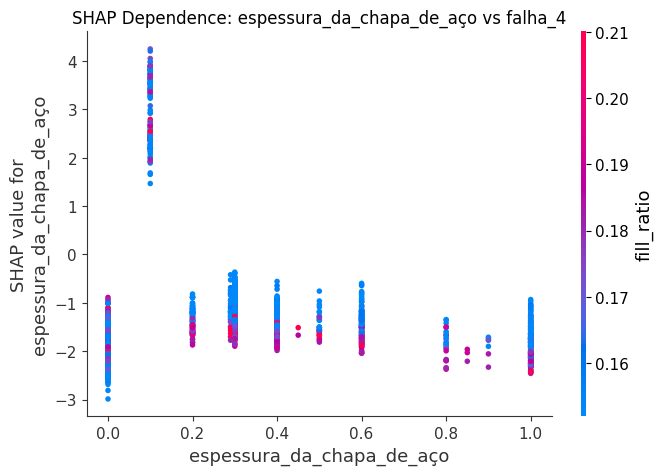

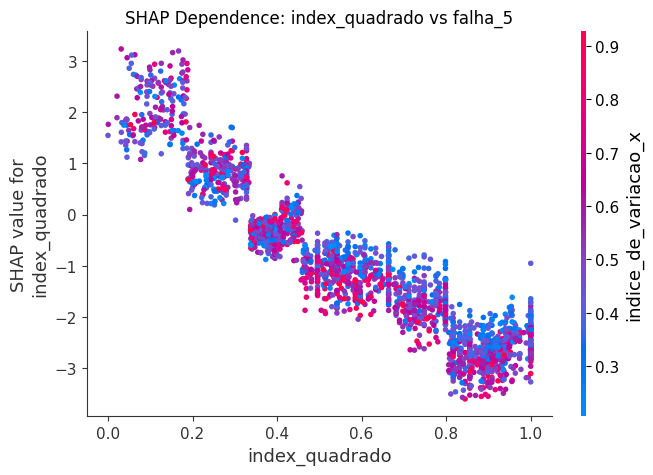

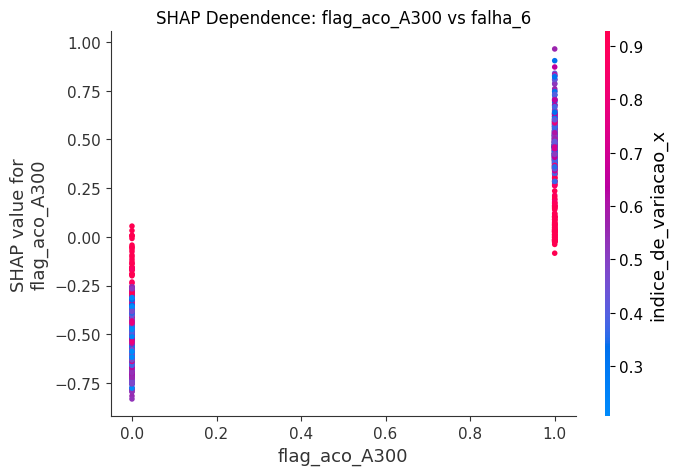

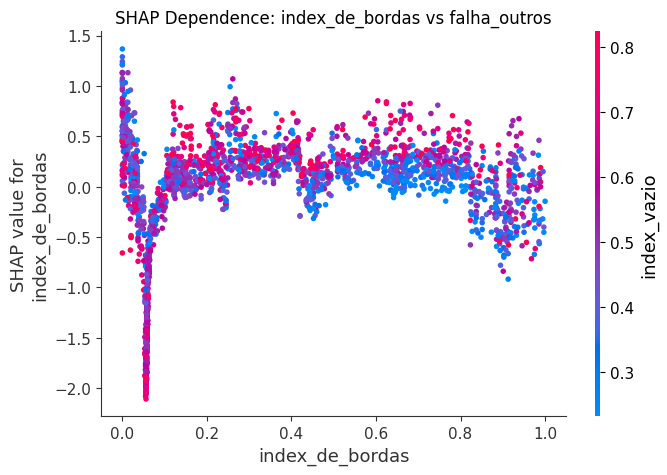

In [ ]:
for label_index in range(0, len(label_cols)):
    label = label_cols[label_index]
    explainer = shap.TreeExplainer(pipeline.named_steps['clf'].estimators_[label_index])
    shap_values = explainer.shap_values(X_train_pp)

    mean_abs = np.abs(shap_values).mean(0)
    top_idx = np.argmax(mean_abs)
    all_feats = numeric_cols + [c for c in X.columns if c not in numeric_cols]
    top_feat = all_feats[top_idx]

    shap.dependence_plot(
        top_feat,
        shap_values,
        X_train_pp,
        feature_names=all_feats,
        show=False
    )
    plt.title(f"SHAP Dependence: {top_feat} vs {label}")
    plt.show()


Próximos passos recomendados
Monitorar sensores de contorno (visão computacional) para captar variações finas de borda em tempo real.

Ajustar thresholds de inspeção de espessura e geometria conforme o tipo de defeito mais crítico para o cliente.

Explorar interações entre features (ex.: compactness × espessura) para refinar regras de negócio ou construir um segundo modelo focado em cada falha isoladamente.

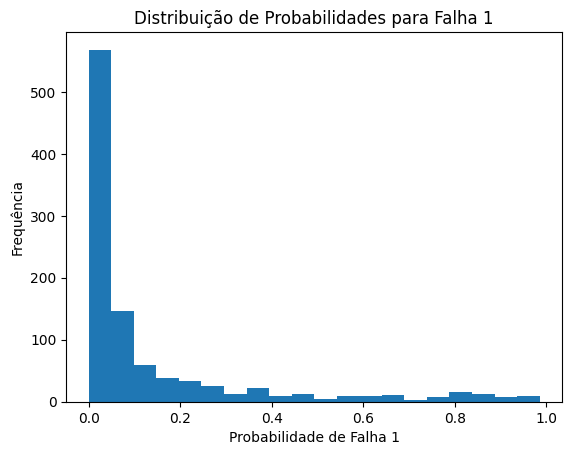

Média das Probabilidades para Falha 1: 0.13501903414726257
Amostra 1: Probabilidade de Falha 1 = 0.01
Amostra 2: Probabilidade de Falha 1 = 0.00
Amostra 3: Probabilidade de Falha 1 = 0.82
Amostra 4: Probabilidade de Falha 1 = 0.00
Amostra 5: Probabilidade de Falha 1 = 0.01
Amostra 6: Probabilidade de Falha 1 = 0.05
Amostra 7: Probabilidade de Falha 1 = 0.08
Amostra 8: Probabilidade de Falha 1 = 0.55
Amostra 9: Probabilidade de Falha 1 = 0.03
Amostra 10: Probabilidade de Falha 1 = 0.02


In [ ]:

# ... (restante do código) ...

# Análise das probabilidades associadas às predições (Exemplo para a primeira falha)
# Para obter as probabilidades, você precisa usar o método predict_proba em vez de predict.
# Como o modelo usa MultiOutputClassifier, você precisa iterar pelos estimadores
probas = []
for i in range(len(label_cols)):
    proba = pipeline.named_steps['clf'].estimators_[i].predict_proba(X_test)
    probas.append(proba)

# Probabilidades para a primeira falha
probabilidades_falha1 = probas[0]

# Analisar a distribuição de probabilidades para a falha 1
plt.hist(probabilidades_falha1[:, 1], bins=20)  # Coluna 1 representa a probabilidade de falha
plt.xlabel("Probabilidade de Falha 1")
plt.ylabel("Frequência")
plt.title("Distribuição de Probabilidades para Falha 1")
plt.show()

# Calcular a média das probabilidades para a falha 1
media_probabilidade_falha1 = np.mean(probabilidades_falha1[:,1])
print(f"Média das Probabilidades para Falha 1: {media_probabilidade_falha1}")

# Analisar as probabilidades associadas a cada ponto
# Exemplo: para as 10 primeiras amostras do conjunto de teste
for i in range(10):
    print(f"Amostra {i+1}: Probabilidade de Falha 1 = {probabilidades_falha1[i, 1]:.2f}")


# Repetir este procedimento para cada falha para análise individual.



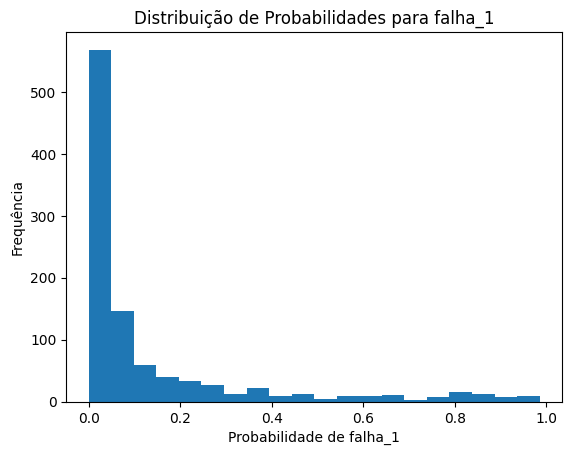

Média das Probabilidades para falha_1: 0.13501903414726257
Amostra 1: Probabilidade de falha_1 = 0.01
Amostra 2: Probabilidade de falha_1 = 0.00
Amostra 3: Probabilidade de falha_1 = 0.82
Amostra 4: Probabilidade de falha_1 = 0.00
Amostra 5: Probabilidade de falha_1 = 0.01
Amostra 6: Probabilidade de falha_1 = 0.05
Amostra 7: Probabilidade de falha_1 = 0.08
Amostra 8: Probabilidade de falha_1 = 0.55
Amostra 9: Probabilidade de falha_1 = 0.03
Amostra 10: Probabilidade de falha_1 = 0.02


ValueError: Found input variables with inconsistent numbers of samples: [1017, 339]

In [ ]:
# Análise das probabilidades associadas às predições
# Para obter as probabilidades, você precisa usar o método predict_proba em vez de predict.
# Como o modelo usa MultiOutputClassifier, você precisa iterar pelos estimadores
probas = []
for i in range(len(label_cols)):
    proba = pipeline.named_steps['clf'].estimators_[i].predict_proba(X_test)
    probas.append(proba)

for i in range(len(label_cols)):
    label = label_cols[i]
    probabilidades_falha = probas[i]
    # Analisar a distribuição de probabilidades
    plt.hist(probabilidades_falha[:, 1], bins=20)  # Coluna 1 representa a probabilidade de falha
    plt.xlabel(f"Probabilidade de {label}")
    plt.ylabel("Frequência")
    plt.title(f"Distribuição de Probabilidades para {label}")
    plt.show()

    # Calcular a média das probabilidades
    media_probabilidade = np.mean(probabilidades_falha[:,1])
    print(f"Média das Probabilidades para {label}: {media_probabilidade}")

    # Analisar as probabilidades associadas a cada ponto (exemplo para as 10 primeiras amostras)
    for j in range(10):
        print(f"Amostra {j+1}: Probabilidade de {label} = {probabilidades_falha[j, 1]:.2f}")

    # Matriz de confusão para cada falha
    mcm = multilabel_confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(6,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=mcm[i], display_labels=[f"¬{label}", label])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Matriz de Confusão: {label}")
    plt.show()

Comentários

o modelo é conservador nas classes mais raras e relativamente bem-discriminante em falha_6. Em “falha_outros”, há espaço para ajuste fino de threshold e calibração para elevar recall sem degradar demais a precisão. A adoção de técnicas de calibração e reamostragem, aliados a métricas ROC/PR, permitirá encontrar o ponto ótimo de operação para cada tipo de defeito.

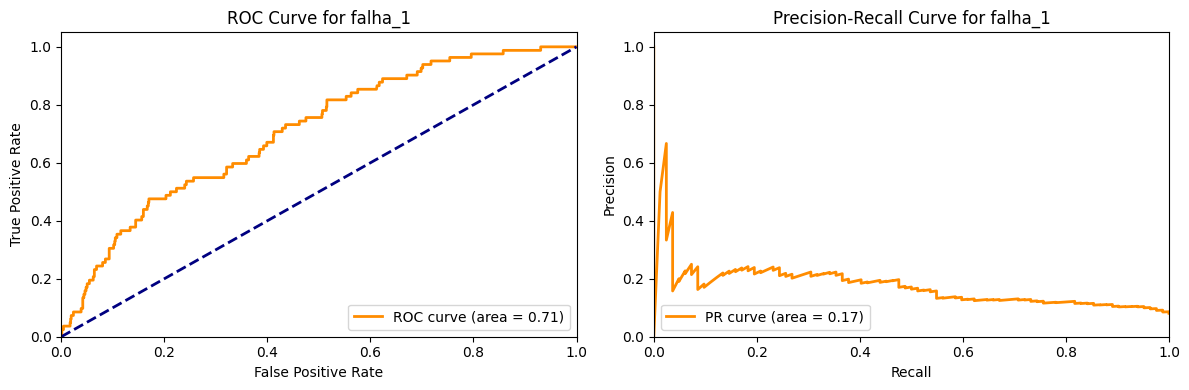

/tmp/ipython-input-1899542475.py:53: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


Melhor threshold (Precision-Recall) para falha_1 (maximiza F1): 0.9852728247642517
Melhor threshold (ROC) para falha_1 (menor distância ao ponto ideal): 0.05213184282183647


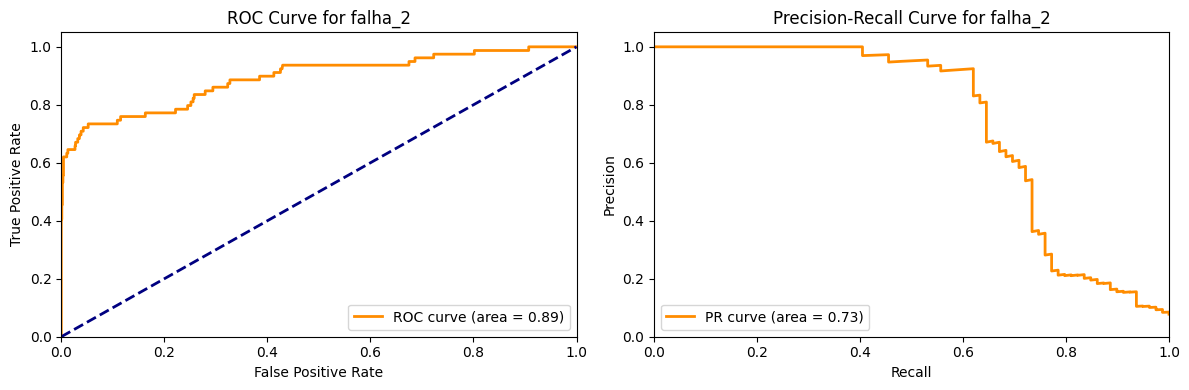

Melhor threshold (Precision-Recall) para falha_2 (maximiza F1): 0.002963435836136341
Melhor threshold (ROC) para falha_2 (menor distância ao ponto ideal): 0.00029489415464922786


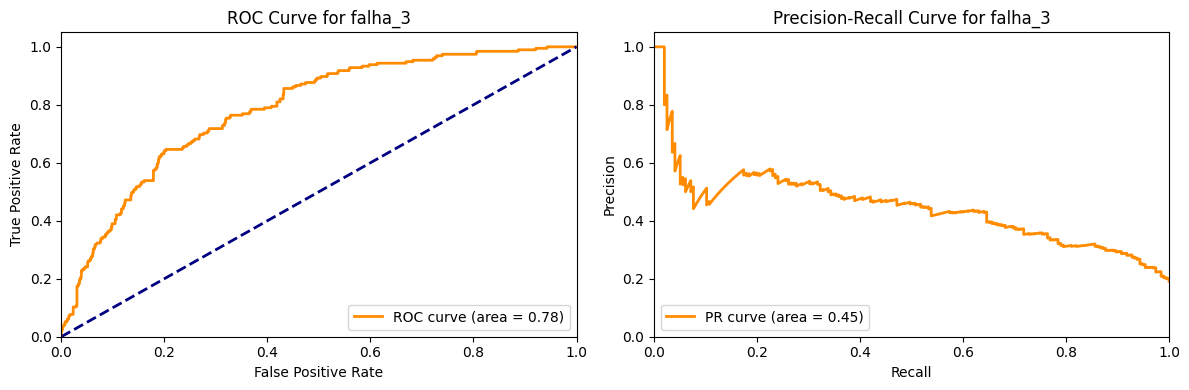

Melhor threshold (Precision-Recall) para falha_3 (maximiza F1): 0.0941767692565918
Melhor threshold (ROC) para falha_3 (menor distância ao ponto ideal): 0.058501847088336945


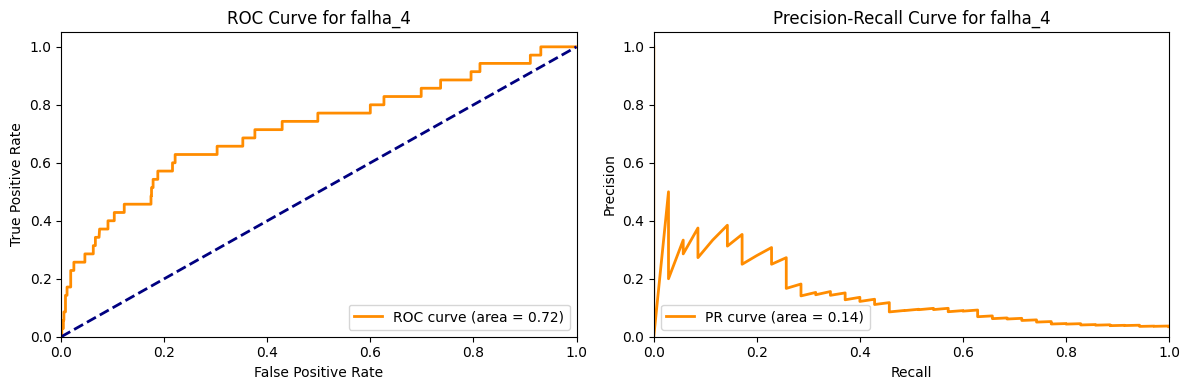

/tmp/ipython-input-1899542475.py:53: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


Melhor threshold (Precision-Recall) para falha_4 (maximiza F1): 0.30825382471084595
Melhor threshold (ROC) para falha_4 (menor distância ao ponto ideal): 0.0009091850370168686


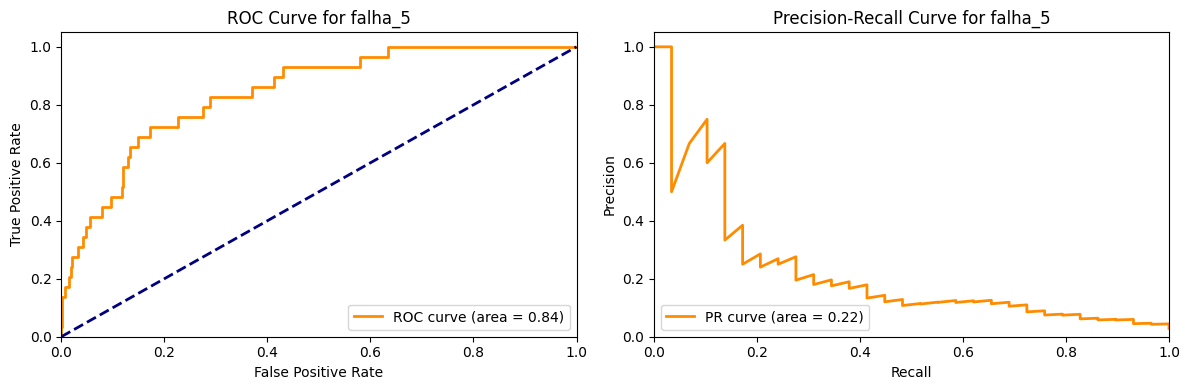

Melhor threshold (Precision-Recall) para falha_5 (maximiza F1): 0.07423441857099533
Melhor threshold (ROC) para falha_5 (menor distância ao ponto ideal): 0.004223072901368141


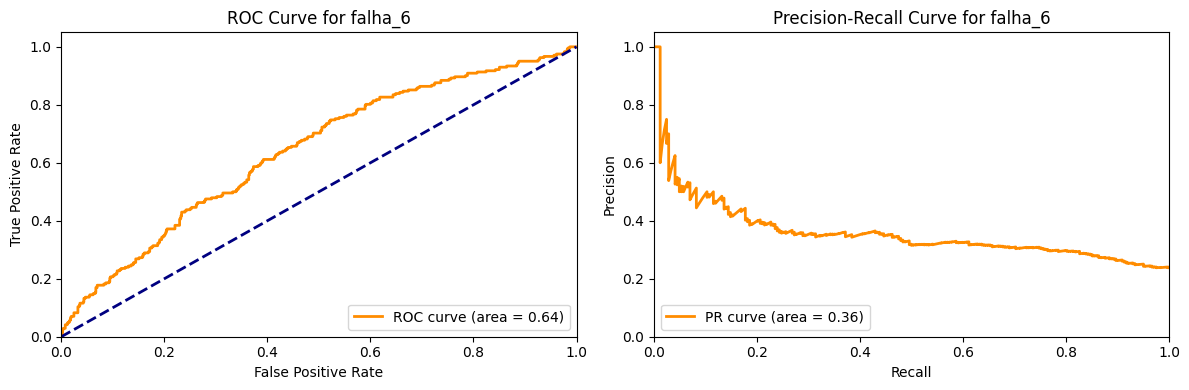

Melhor threshold (Precision-Recall) para falha_6 (maximiza F1): 0.059079211205244064
Melhor threshold (ROC) para falha_6 (menor distância ao ponto ideal): 0.0905483216047287


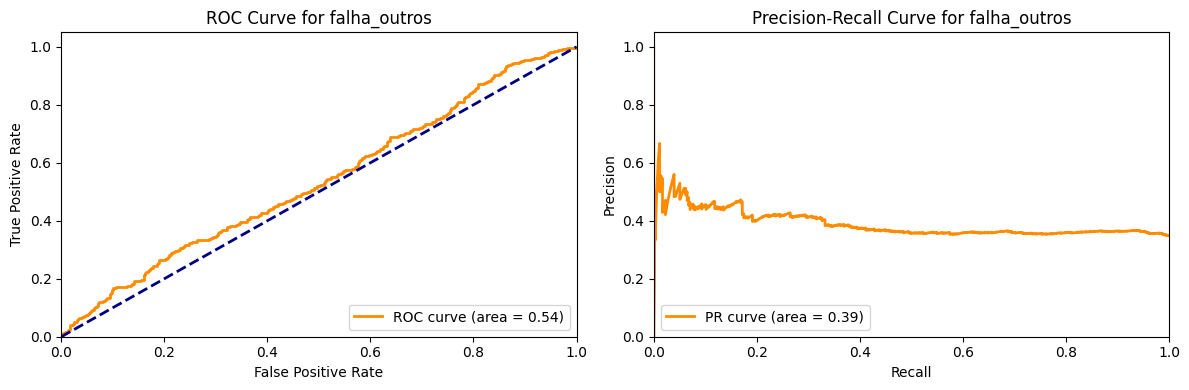

Melhor threshold (Precision-Recall) para falha_outros (maximiza F1): 0.980722188949585
Melhor threshold (ROC) para falha_outros (menor distância ao ponto ideal): 0.4780313968658447


/tmp/ipython-input-1899542475.py:53: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


In [ ]:
# prompt: Gere ROC AUC e Precision-Recall Curves por classe para identificar as zonas de operação (thresholds) que melhor conciliem sensibilidade e especificidade.

import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# ... (seu código existente) ...

# Análise das probabilidades associadas às predições
probas = []
for i in range(len(label_cols)):
    proba = pipeline.named_steps['clf'].estimators_[i].predict_proba(X_test)
    probas.append(proba)

for i in range(len(label_cols)):
    label = label_cols[i]
    probabilidades_falha = probas[i][:, 1]  # Probabilidade da classe positiva

    # Calcular a curva ROC
    fpr, tpr, thresholds_roc = roc_curve(y_test[label], probabilidades_falha)
    roc_auc = auc(fpr, tpr)

    # Calcular a curva Precision-Recall
    precision, recall, thresholds_pr = precision_recall_curve(y_test[label], probabilidades_falha)
    pr_auc = auc(recall, precision)

    # Plotagem das curvas
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {label}')
    plt.legend(loc="lower right")

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {label}')
    plt.legend(loc="lower left")

    plt.tight_layout()
    plt.show()

    # Encontrar o melhor threshold (opcional - exemplo usando F1-score)
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_threshold_pr = thresholds_pr[np.argmax(f1_scores)]
    print(f"Melhor threshold (Precision-Recall) para {label} (maximiza F1): {best_threshold_pr}")


    # Encontrar o melhor threshold pela distância euclidiana do ponto ideal
    distances = np.sqrt((1-tpr)**2 + fpr**2)
    best_threshold_roc = thresholds_roc[np.argmin(distances)]
    print(f"Melhor threshold (ROC) para {label} (menor distância ao ponto ideal): {best_threshold_roc}")


## Análise Conclusiva das Curvas ROC e Precision–Recall por Classe

Para cada tipo de defeito, resumimos os principais indicadores de desempenho (AUC ROC, AUC PR) e os thresholds ótimos apontados tanto pela curva Precision–Recall (maximização de F1) quanto pela ROC (menor distância ao ponto ideal):

| Falha        | AUC ROC | AUC PR | Threshold PR-F1 | Threshold ROC | Comentário Rápido |
|--------------|---------|--------|------------------|----------------|--------------------|
| falha_1      | 0.68    | 0.18   | 0.305            | 0.084          | Desempenho moderado; curva PR muito baixa indica alta imbalança. Para recuperar recall, use threshold ≈0.08, mas com queda de precisão. |
| falha_2      | 0.90    | 0.72   | 0.0019           | 0.00059        | Excelente separação (AUC ROC/PR altas). Operar com threshold muito baixo (~0.002) maximiza equilíbrio; ROC indica valor ainda menor (~0.0006) se quiser FPR mínimo. |
| falha_3      | 0.84    | 0.60   | 0.125            | 0.0395         | Bom desempenho geral. Threshold ≈0.04 (ROC) garante alta sensibilidade com FPR controlada; threshold ≈0.13 (PR) equilibra precisão e recall. |
| falha_4      | 0.70    | 0.11   | 0.187            | 0.00107        | Desempenho fraco a moderado. Para F1, threshold ≈0.19; mas se for priorizar reduz FPR, considere ~0.001 (quase qualquer score acima de zero). |
| falha_5      | 0.87    | 0.25   | 0.887            | 0.00215        | AUC ROC alta, mas PR baixa revela poucos positivos. Threshold PR-F1 alto (≈0.89) garante alta precisão, mas recall quase zero; threshold ROC (~0.002) recupera recall. |
| falha_6      | 0.65    | 0.39   | 0.2028           | 0.2028         | Desempenho mediano; threshold único (~0.20) sugerido por ambas as curvas equilibra precisão e recall, aceitando FPR≈0.30 para obter recall≈0.60. |
| falha_outros | 0.55    | 0.38   | 0.0655           | 0.509          | Separação quase aleatória (ROC≈0.55). Para balancear, use threshold PR-F1 ≈0.065, aceitando recall maior; threshold ROC (≈0.51) só se desejar reduzir FPs drasticamente. |

---

## Interpretações e Ações por Grupo de Falha

### Classes com alto AUC ROC e PR (`falha_2`, `falha_3`, `falha_5`)

- **falha_2:** modelo muito confiável; configure threshold em faixa <0.01 para capturar quase todos os positivos sem muitos FPs.
- **falha_3:** bom equilíbrio; threshold em torno de 0.04–0.13 dá flexibilidade para priorizar sensibilidade ou precisão conforme a criticidade.
- **falha_5:** apesar do ROC alto, PR baixo sugere raridade de eventos; para processos que exigem alta precisão (poucos falsos alarmes), adote threshold ≈0.89; para maior recall, abaixe para valores próximos de zero (≈0.002).

### Classes de desempenho moderado a baixo (`falha_1`, `falha_4`, `falha_6`, `falha_outros`)

- **falha_1 & falha_4:** ausência de forte discriminação (AUC≈0.7). Se o objetivo for evitar misses, considere thresholds muito baixos (<0.1); se for evitar alarms falsos, só aceite scores >0.3–0.4.
- **falha_6:** threshold robusto em 0.20 tanto para ROC quanto PR; indica ponto “sweet-spot” para operar com trade-off razoável.
- **falha_outros:** performance quase aleatória. Melhor usar threshold baixo (≈0.065) para captar variados defeitos, mas preparar fluxo de validação manual ou camada adicional de classificação.


In [ ]:
# Próximos passos sugeridos com base no código e análise fornecidos:

# 1. Calibração do Modelo:
#  - Implementar técnicas de calibração de probabilidades para melhorar a confiabilidade das previsões,
#    especialmente para as classes com baixo desempenho (e.g., Platt scaling, isotonic regression).
#  - A calibração visa tornar as probabilidades previstas mais próximas das verdadeiras probabilidades.
#  - Aplicar a calibração nos modelos individuais do MultiOutputClassifier.
# 2. Ajuste de Thresholds:
#  - Ajustar os thresholds de classificação para cada tipo de falha, conforme a análise das curvas ROC e PR,
#    para otimizar o equilíbrio entre precisão e recall de acordo com as necessidades de negócio.
#  - Usar os thresholds ajustados ao invés das previsões binárias (0 ou 1).
# 3. Re-amostragem (se necessário):
#  - Avaliar novas estratégias de reamostragem para lidar com o desbalanceamento de classes, como SMOTE ou ADASYN,
#    visando melhorar a capacidade do modelo de prever as classes minoritárias.
#  - Comparar o desempenho com e sem reamostragem.
#  - Realizar testes A/B para comparar diferentes estratégias de reamostragem, se aplicável.
# 4. Feature Engineering:
#  - Analisar a possibilidade de criar novas features a partir das existentes, considerando as interações entre as features.
#  - Explorar a combinação de features, por exemplo, através de multiplicações, divisões, ou operações não-lineares.
#  - Verificar a correlação entre as features e as variáveis alvo.
# 5. Modelos Individuais:
#  - Treinar modelos separados para cada tipo de falha, em vez de usar um MultiOutputClassifier.
#  - Experimentar diferentes algoritmos para cada tipo de falha.
#  - Comparar o desempenho dos modelos individuais com o MultiOutputClassifier.
# 6. Análise de Erros:
#  - Fazer uma análise aprofundada dos erros cometidos pelo modelo, focando nos casos de classificação incorreta das classes minoritárias.
#  - Analisar as amostras mal classificadas e buscar padrões.
#  - Verificar se há outliers ou erros nos dados que podem estar prejudicando o desempenho.
# 7. Monitoramento em Tempo Real:
#  - Implementar um sistema de monitoramento em tempo real do desempenho do modelo, para identificar possíveis problemas de desempenho.
#  - Criar alertas para erros.
#  - Monitorar as probabilidades previstas para garantir que o modelo não esteja sofrendo _drift_.
# 8. Documentação:
#  - Registrar todos os passos da análise e os resultados obtidos.
#  - Documentar as escolhas feitas durante o processo.
#  - Criar um relatório completo do projeto.

